In [ ]:
# OASIS Infobyte Data Science Internship

## Task 2: Unemployment Analysis with Python

### Objective

This project analyzes unemployment trends in India using Python.

The analysis includes:

- Data loading and inspection
- Data cleaning and preprocessing
- Missing-value analysis
- Region-wise unemployment analysis
- Top 10 regions with highest unemployment
- Monthly unemployment trends
- Regional time-series comparison
- Correlation analysis
- Pre-COVID vs Post-COVID comparison
- Data visualization
- Key observations and conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
# Load the correct unemployment dataset

DATA_FILE = "Unemployment in India.csv"

try:
    df = pd.read_csv(DATA_FILE, encoding="utf-8")
except UnicodeDecodeError:
    print("UTF-8 decoding failed. Loading with latin1 encoding...")
    df = pd.read_csv(DATA_FILE, encoding="latin1")

print("Dataset loaded successfully!")
print("File:", DATA_FILE)
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
File: Unemployment in India.csv
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.00,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.00,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.00,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.00,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.00,44.68,Rural


In [3]:
print("Dataset columns:\n")

for col in df.columns:
    print(repr(col))

Dataset columns:

'Region'
' Date'
' Frequency'
' Estimated Unemployment Rate (%)'
' Estimated Employed'
' Estimated Labour Participation Rate (%)'
'Area'


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (768, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [5]:
print("Missing values in each column:")

display(
    df.isnull().sum().to_frame("Missing Values")
)

Missing values in each column:


,Missing Values
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 27


In [7]:
df.columns = df.columns.astype(str).str.strip()

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [8]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (768, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [9]:
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values.to_frame("Missing Values"))

Missing Values:


,Missing Values
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 27


In [11]:
df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
}, inplace=True)

print("Updated columns:")
print(df.columns.tolist())

Updated columns:
['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area']


In [12]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Date data type:", df["Date"].dtype)

display(df[["Date"]].head())

Date data type: datetime64[ns]


/tmp/ipykernel_250/1010721163.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(


,Date
0,2019-05-31
1,2019-06-30
2,2019-07-31
3,2019-08-31
4,2019-09-30


In [13]:
numeric_columns = [
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Numeric columns:")
print(df[numeric_columns].dtypes)

Numeric columns:
Unemployment_Rate            float64
Employed                     float64
Labour_Participation_Rate    float64
dtype: object


In [14]:
print("Dataset Shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.head())

Dataset Shape: (768, 7)

Missing values:


,Missing Values
Region,28
Date,28
Frequency,28
Unemployment_Rate,28
Employed,28
Labour_Participation_Rate,28
Area,28



Duplicate rows: 27


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.00,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.00,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.00,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.00,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.00,44.68,Rural


In [15]:
display(
    df[
        [
            "Unemployment_Rate",
            "Employed",
            "Labour_Participation_Rate"
        ]
    ].describe()
)

,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.51
max,76.74,45777509.00,72.57


In [16]:
print("Number of unique regions:", df["Region"].nunique())

print("\nRegions:")
print(df["Region"].unique())

Number of unique regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' nan 'Chandigarh']


In [17]:
# Remove rows with missing values
df = df.dropna().copy()

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaned Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Cleaned Dataset Shape: (740, 7)

Missing Values:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

Duplicate Rows: 0


In [18]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2019-05-31 00:00:00
End Date: 2020-06-30 00:00:00


In [19]:
region_unemployment = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

display(region_unemployment.to_frame("Average Unemployment Rate"))

,Average Unemployment Rate
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.59
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


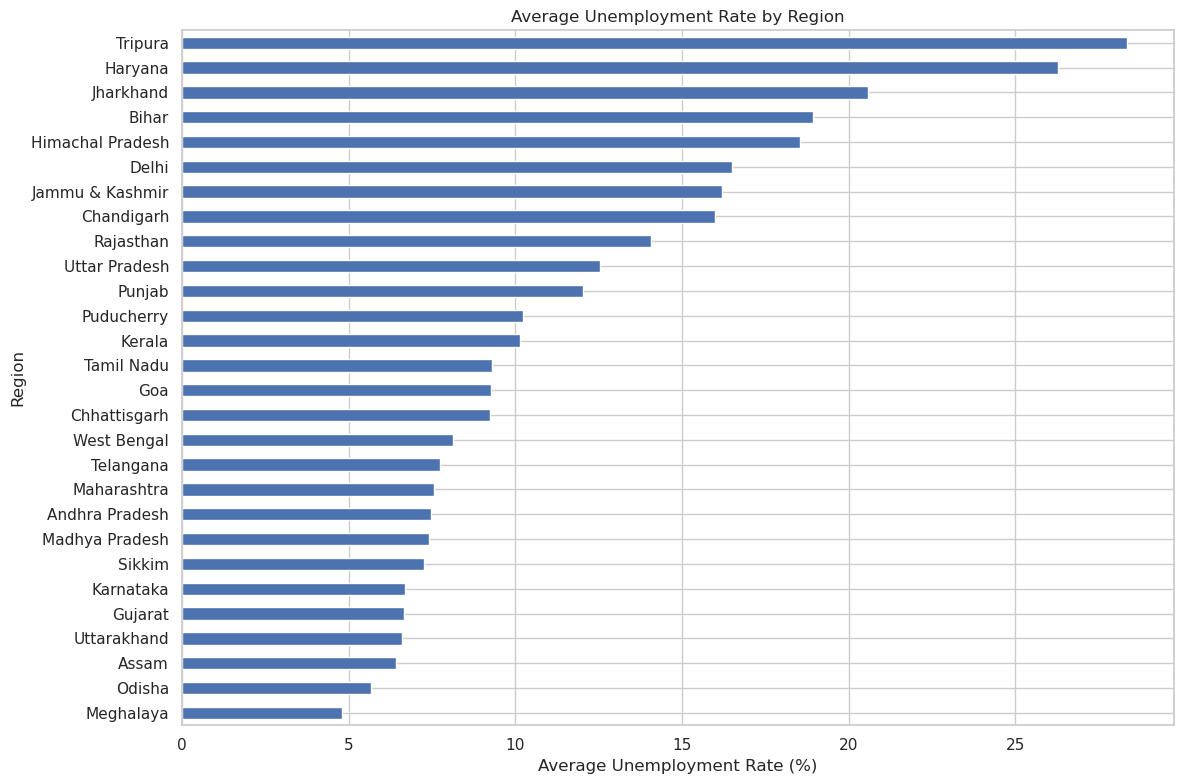

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

region_unemployment.sort_values().plot(
    kind="barh"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The bar chart shows the average unemployment rate across different regions of India. 
There is considerable variation between regions, indicating that unemployment is not 
uniformly distributed across the country. Regions with higher average unemployment 
rates may require greater attention to employment generation and economic development.

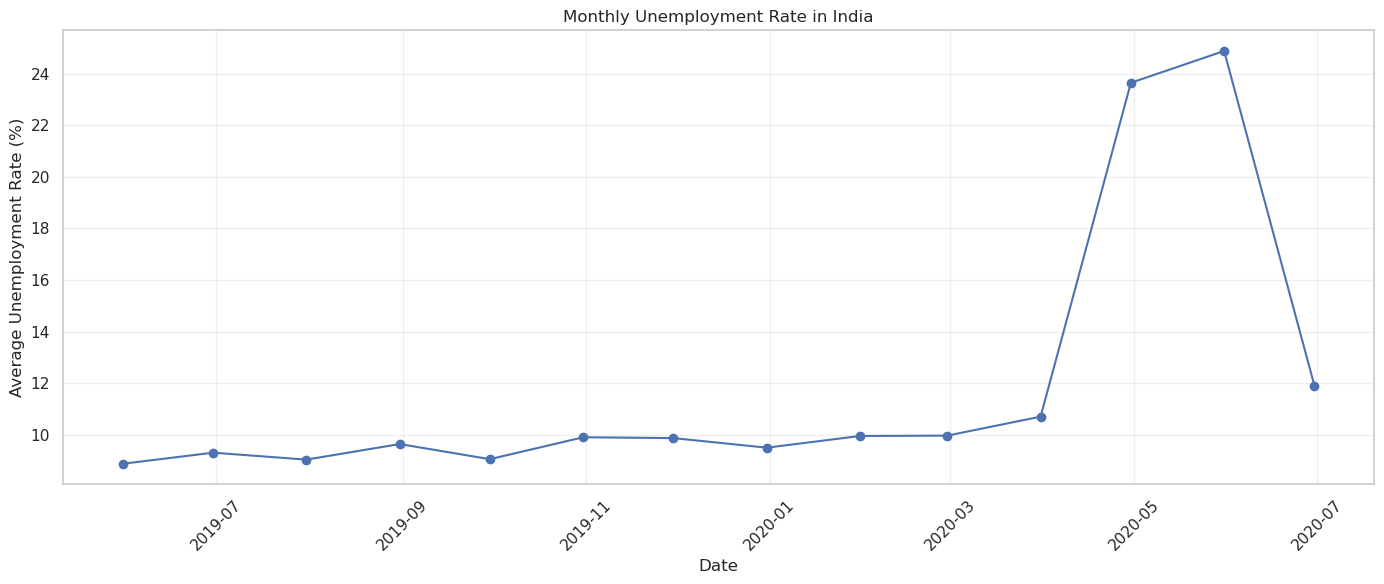

In [21]:
monthly_unemployment = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The time-series graph shows how the average unemployment rate changed over the 
observed period. The trend indicates fluctuations in unemployment over time, with 
noticeable changes during different months. These variations can be associated with 
changes in economic activity and employment conditions.

In [22]:
top_10_regions = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Regions with Highest Average Unemployment Rate:")
display(top_10_regions.to_frame("Average Unemployment Rate"))

Top 10 Regions with Highest Average Unemployment Rate:


,Average Unemployment Rate
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.59
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


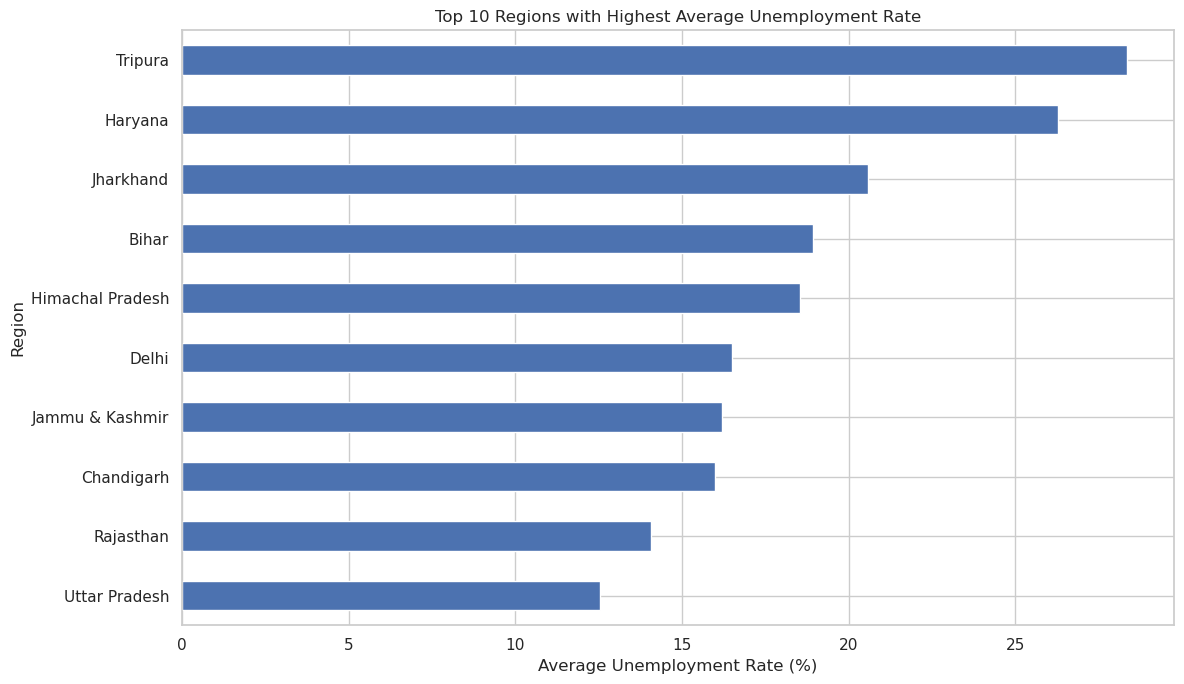

In [23]:
plt.figure(figsize=(12, 7))

top_10_regions.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The chart presents the ten regions with the highest average unemployment rates.
The results show substantial differences in unemployment across regions. The regions
at the top of the chart experienced comparatively higher unemployment during the
study period, highlighting regional differences in employment opportunities.

In [24]:
# Select the three regions with the highest average unemployment
selected_regions = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("Selected regions:")
print(selected_regions)

Selected regions:
['Tripura', 'Haryana', 'Jharkhand']


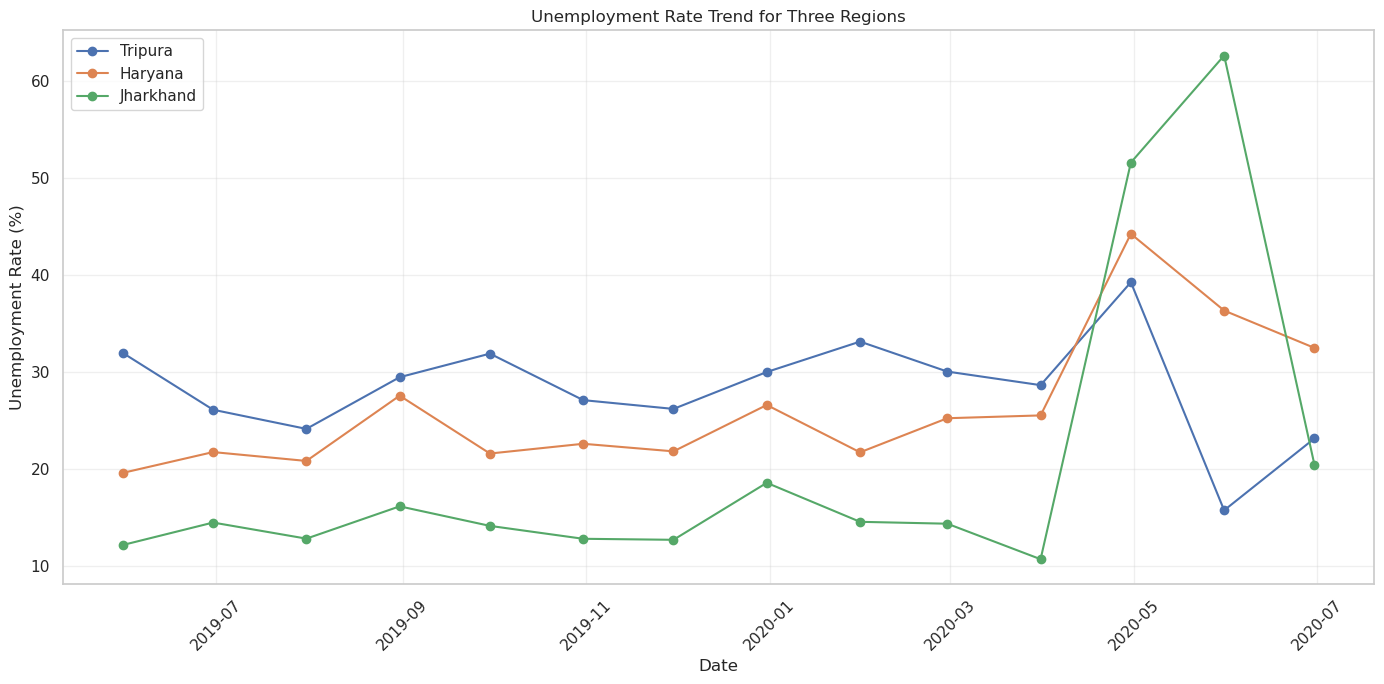

In [25]:
plt.figure(figsize=(14, 7))

for region in selected_regions:
    region_data = (
        df[df["Region"] == region]
        .groupby("Date")["Unemployment_Rate"]
        .mean()
        .sort_index()
    )
    
    plt.plot(
        region_data.index,
        region_data.values,
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Trend for Three Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The time-series comparison demonstrates that unemployment rates varied considerably
among the selected regions. Although the regions follow some common temporal patterns,
the magnitude and timing of changes differ. This indicates that regional economic
conditions and employment opportunities influenced unemployment trends.

In [26]:
correlation_data = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
]

correlation_matrix = correlation_data.corr()

display(correlation_matrix)

,Unemployment_Rate,Employed,Labour_Participation_Rate
Unemployment_Rate,1.00,-0.22,0.00
Employed,-0.22,1.00,0.01
Labour_Participation_Rate,0.00,0.01,1.00


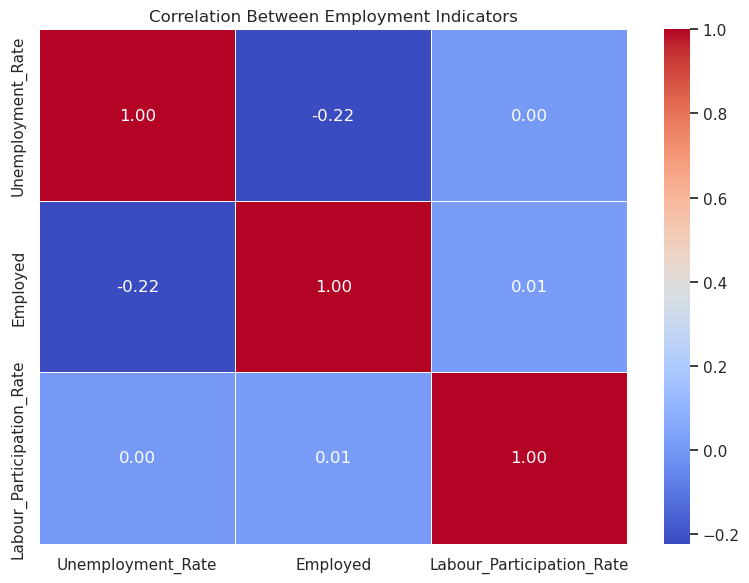

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The correlation heatmap illustrates the relationships between unemployment rate,
estimated employment, and labour participation rate. The correlation coefficients
indicate the strength and direction of relationships among these variables.

A negative correlation between unemployment and employment-related indicators would
suggest that higher unemployment is generally associated with lower employment
levels, while a positive correlation indicates that the two variables tend to move
in the same direction.

In [28]:
covid_start = pd.Timestamp("2020-03-01")

df["Period"] = df["Date"].apply(
    lambda x: "Pre-COVID" if x < covid_start else "COVID/Post-COVID"
)

print(df["Period"].value_counts())

Period
Pre-COVID           536
COVID/Post-COVID    204
Name: count, dtype: int64


In [29]:
period_analysis = (
    df.groupby("Period")[
        [
            "Unemployment_Rate",
            "Employed",
            "Labour_Participation_Rate"
        ]
    ]
    .mean()
)

display(period_analysis)

,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
COVID/Post-COVID,17.77,6517203.34,39.33
Pre-COVID,9.51,7466027.87,43.89


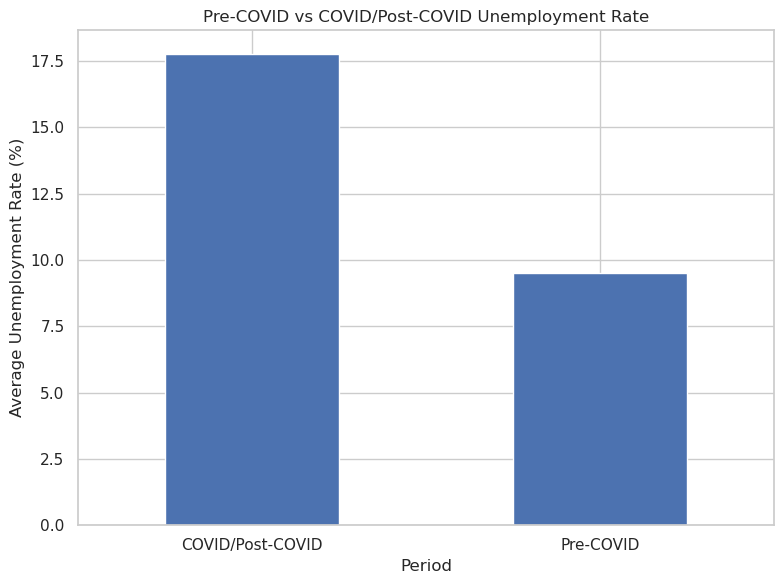

In [30]:
plt.figure(figsize=(8, 6))

period_analysis["Unemployment_Rate"].plot(
    kind="bar"
)

plt.title("Pre-COVID vs COVID/Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The comparison shows the difference in average unemployment rates before and during
the COVID-19/post-COVID period. The COVID-19 period was associated with significant
changes in employment conditions. The comparison helps demonstrate the impact of the
pandemic on India's labour market.

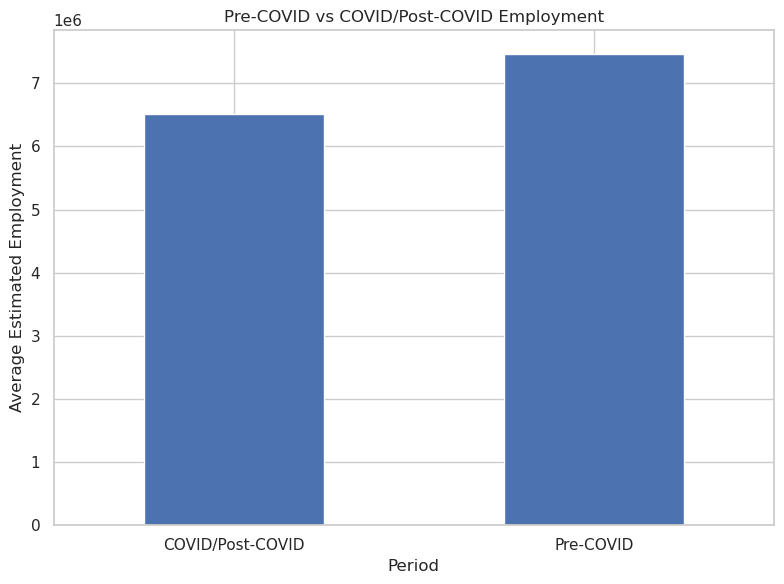

In [31]:
plt.figure(figsize=(8, 6))

period_analysis["Employed"].plot(
    kind="bar"
)

plt.title("Pre-COVID vs COVID/Post-COVID Employment")
plt.xlabel("Period")
plt.ylabel("Average Estimated Employment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The chart compares estimated employment before and during the COVID-19/post-COVID
period. Changes in employment levels indicate the effect of the pandemic and the
subsequent economic conditions on employment.

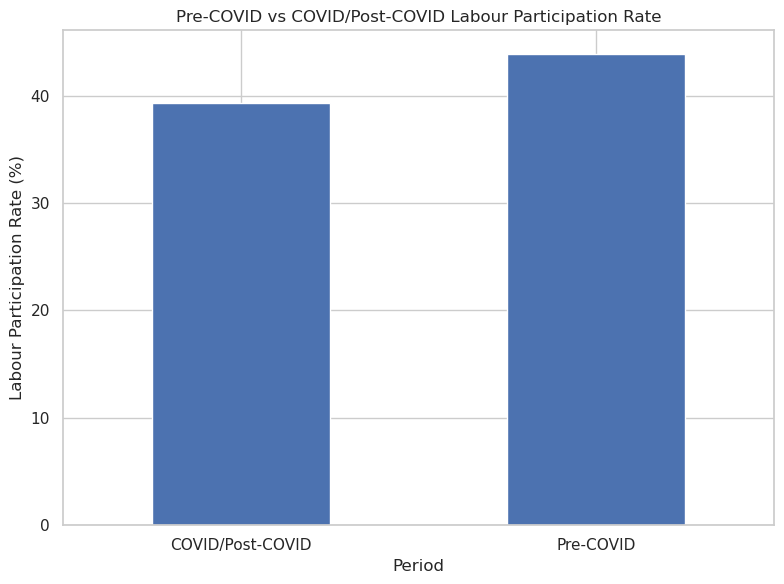

In [32]:
plt.figure(figsize=(8, 6))

period_analysis["Labour_Participation_Rate"].plot(
    kind="bar"
)

plt.title("Pre-COVID vs COVID/Post-COVID Labour Participation Rate")
plt.xlabel("Period")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
region_employment = (
    df.groupby("Region")["Employed"]
    .mean()
    .sort_values(ascending=False)
)

display(
    region_employment.head(10).to_frame(
        "Average Estimated Employment"
    )
)

,Average Estimated Employment
Region,
Uttar Pradesh,28094832.18
Maharashtra,19990195.86
West Bengal,17198538.00
Bihar,12366189.14
Tamil Nadu,12269546.75
Gujarat,11402012.79
Madhya Pradesh,11115484.32
Karnataka,10667119.29
Rajasthan,10041064.75


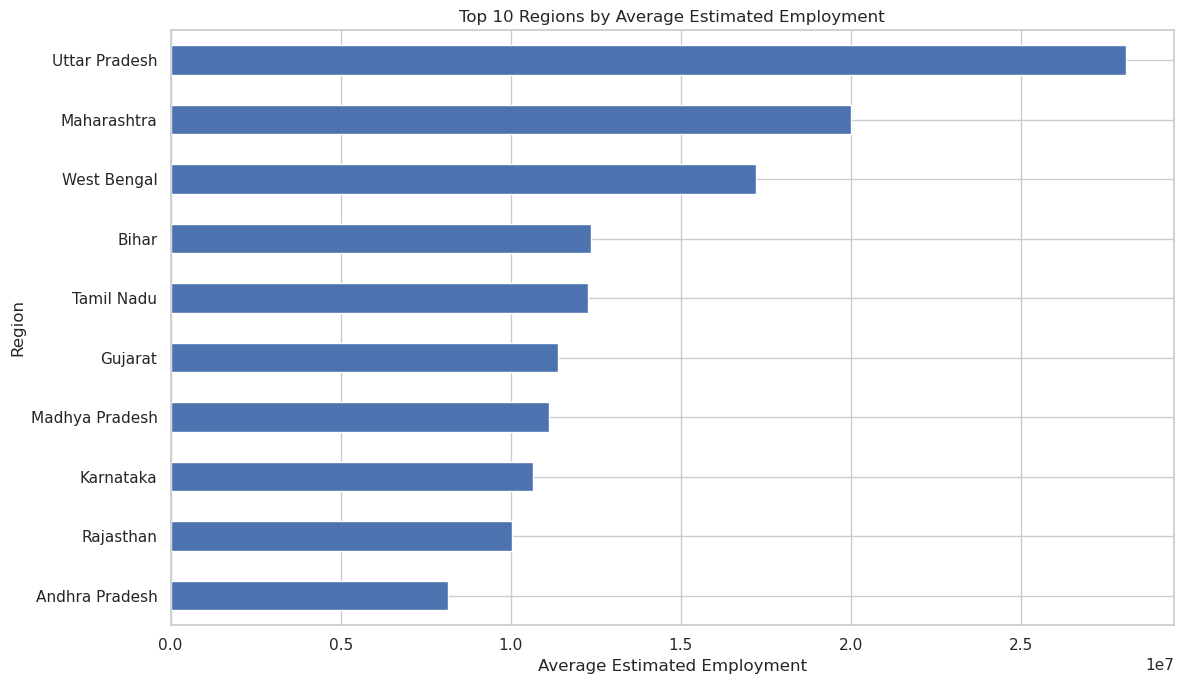

In [63]:
plt.figure(figsize=(12, 7))

region_employment.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions by Average Estimated Employment")
plt.xlabel("Average Estimated Employment")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The chart identifies the regions with the highest average estimated employment.
Larger values generally reflect regions with a larger estimated employed population.
However, employment totals should be interpreted together with unemployment and
labour participation rates because population size differs between regions.

In [35]:
area_unemployment = (
    df.groupby("Area")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

display(
    area_unemployment.to_frame(
        "Average Unemployment Rate"
    )
)

,Average Unemployment Rate
Area,
Urban,13.17
Rural,10.32


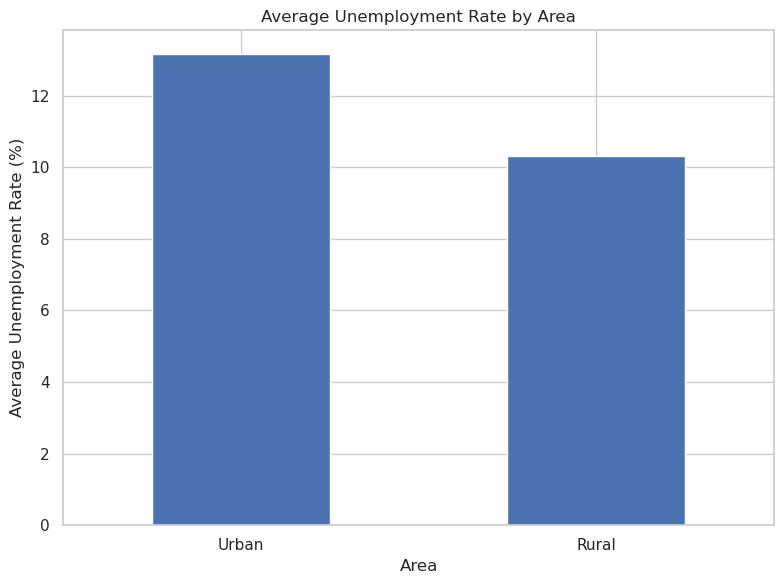

In [36]:
plt.figure(figsize=(8, 6))

area_unemployment.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
### Observation

The comparison between rural and urban areas shows differences in unemployment
conditions. The variation may reflect differences in economic activity, employment
opportunities, industrialization, and the structure of the labour market between
rural and urban areas.

In [37]:
summary = pd.DataFrame({
    "Metric": [
        "Average Unemployment Rate",
        "Maximum Unemployment Rate",
        "Minimum Unemployment Rate",
        "Average Employment",
        "Average Labour Participation Rate"
    ],
    "Value": [
        df["Unemployment_Rate"].mean(),
        df["Unemployment_Rate"].max(),
        df["Unemployment_Rate"].min(),
        df["Employed"].mean(),
        df["Labour_Participation_Rate"].mean()
    ]
})

summary["Value"] = summary["Value"].round(2)

display(summary)

,Metric,Value
0,Average Unemployment Rate,11.79
1,Maximum Unemployment Rate,76.74
2,Minimum Unemployment Rate,0.00
3,Average Employment,7204460.03
4,Average Labour Participation Rate,42.63


In [ ]:
# Conclusion

This project analyzed unemployment trends in India using Python and exploratory
data analysis techniques.

The dataset was cleaned by handling missing values, removing duplicate records,
converting dates into the appropriate format, and converting numerical variables
to numeric data types.

The analysis examined regional unemployment rates, monthly unemployment trends,
the top regions with the highest unemployment, employment levels, labour
participation rates, and differences between rural and urban areas.

A correlation heatmap was used to understand relationships among unemployment,
employment, and labour participation indicators.

The pre-COVID and COVID/post-COVID comparison provided insight into changes in
India's labour market during the pandemic period.

Overall, the analysis demonstrates substantial regional and temporal variation in
unemployment and highlights the importance of examining multiple employment
indicators when evaluating labour-market conditions.